<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/cGOOUZw.png" width="120">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#1957d1" size="7">|</font><br>
            <font color="#1957d1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="5">
                <b>Monografia de Grado - Ciencia de Datos</b>
            </font></p>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="4">
                Tecnicas de fine-tuning para LLMs: revision sistematica y evaluacion comparativa
            </font></p>
            <p style="font-style: oblique;"><font color="#1957d1" size="3">
                Por: Francisco Flores
            </font></p>
        </td>
    </tr>
</table>

## <font color='#1957d1'> Importaciones </font>

In [1]:
# - Imports -
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

## <font color='#1957d1'> Configuracion global </font>

In [2]:
# - Paleta y rutas -
COLOR_1 = "#1957d1"
COLOR_2 = "#5b8dee"
COLOR_3 = "#a8c4f5"
COLOR_4 = "#0d3a8e"

# Paleta para graficos con multiples categorias: cuatro tonos con buen contraste
COLORES_CATEGORIAS = ["#0d3a8e", "#1957d1", "#5b8dee", "#93b8f5"]

PALETTE_DOMINIOS = {
    "Salud y Biomedicina":            "#0d3a8e",
    "Lenguaje y Humanidades":         "#1957d1",
    "Ciencias Exactas y Computación": "#5b8dee",
    "Industria y Negocios":           "#93b8f5",
}

RUTA_CSV = Path(".")
RUTA_OUT = Path("Figuras")
RUTA_OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

## <font color='#1957d1'> Carga de datos </font>

In [3]:
# - Carga de los tres CSV del pipeline PRISMA -
df_fase1_orig = pd.read_csv("Exports/Phase1/phase1_screening_results.csv")
df_fase2_orig = pd.read_csv("Exports/Phase2/phase2_screening_results.csv")
df_fase3_orig = pd.read_csv("Exports/Phase3/phase3_qa_results.csv")

print(f"Fase 1: {len(df_fase1_orig)} registros")
print(f"Fase 2: {len(df_fase2_orig)} registros")
print(f"Fase 3: {len(df_fase3_orig)} registros")

Fase 1: 139 registros
Fase 2: 101 registros
Fase 3: 84 registros


## <font color='#1957d1'> Copias de trabajo </font>

In [4]:
# - Copias para no modificar los originales -
df_fase1 = df_fase1_orig.copy()
df_fase2 = df_fase2_orig.copy()
df_fase3 = df_fase3_orig.copy()

## <font color='#1957d1'> Figura 1 - Articulos que cumplieron cada criterio de elegibilidad (Fase 2) </font>

In [5]:
# - Conteo de articulos excluidos por cada criterio Q1-Q5 -
dic_criterios = {
    "q1_metricas":  "Q1 - Reporta metricas\ncuantitativas",
    "q2_tecnica":   "Q2 - Implementa tecnica\nen scope",
    "q3_dataset":   "Q3 - Identifica\nel dataset",
    "q4_contexto":  "Q4 - Especifica tarea\ny modelo base",
    "q5_empirico":  "Q5 - Estudio empirico\noriginal",
}

sr_excluidos = pd.Series({
    dic_criterios[col]: int((df_fase2[col] == False).sum())
    for col in dic_criterios
})
sr_excluidos

Q1 - Reporta metricas\ncuantitativas     1
Q2 - Implementa tecnica\nen scope        7
Q3 - Identifica\nel dataset              0
Q4 - Especifica tarea\ny modelo base    16
Q5 - Estudio empirico\noriginal          1
dtype: int64

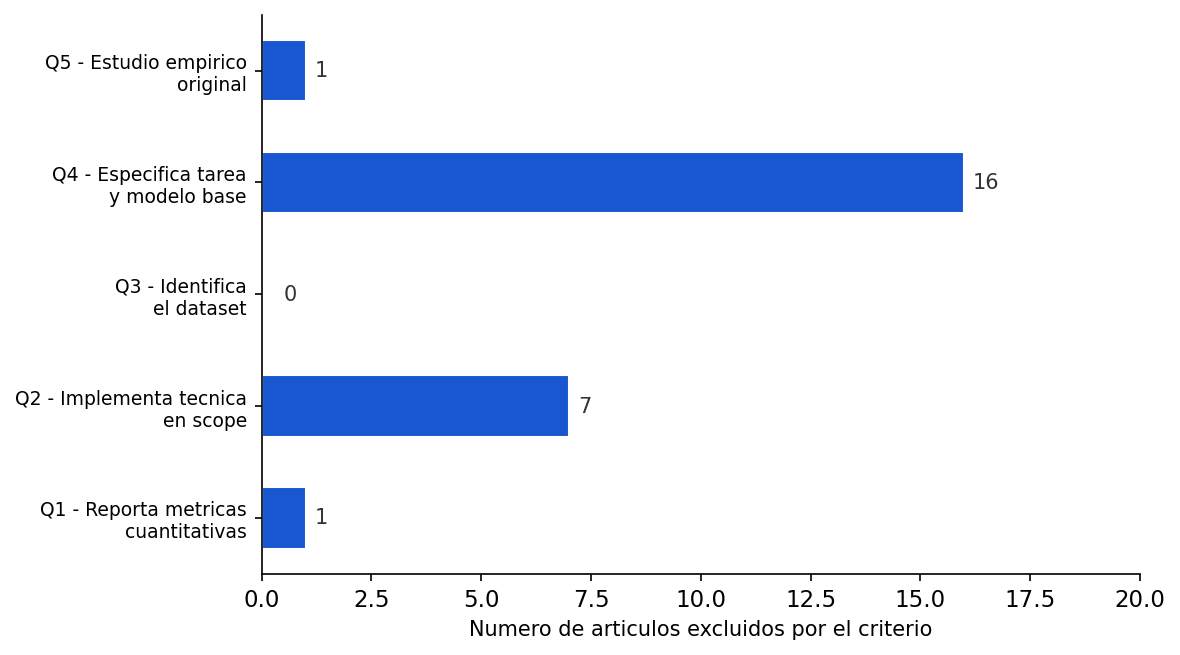

In [6]:
# - Figura 1 -
fig, ax = plt.subplots(figsize=(8, 4.5))

lst_colores_q = [COLOR_1 if v > 0 else COLOR_3 for v in sr_excluidos.values]
bars = ax.barh(sr_excluidos.index, sr_excluidos.values,
               color=lst_colores_q, edgecolor="white", height=0.55)

for bar, int_val in zip(bars, sr_excluidos.values):
    ax.text(max(bar.get_width() + 0.2, 0.5),
            bar.get_y() + bar.get_height() / 2,
            str(int_val), va="center", fontsize=10, color="#333")

ax.set_xlabel("Numero de articulos excluidos por el criterio", fontsize=10)
ax.set_xlim(0, 20)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig1_criterios_elegibilidad.png")
plt.show();

## <font color='#1957d1'> Figura 2 - Distribucion del corpus por dominio de aplicacion </font>

In [7]:
# - Conteo por dominio desde apendice-datos.md -
import re as _re

def _parse_apendice_fig2(path):
    papers, current = [], {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip()
            if line.startswith("### "):
                if current:
                    papers.append(current)
                current = {"clave": line[4:].strip()}
            elif line.startswith("- ") and current:
                m = _re.match(r"- (.+?):\s*(.+)", line)
                if m:
                    current[m.group(1).strip()] = m.group(2).strip()
    if current:
        papers.append(current)
    return papers

_papers_fig2 = _parse_apendice_fig2(Path("../apendice-datos.md"))
print(f"Papers leidos desde apendice-datos.md: {len(_papers_fig2)}")

_conteos = {}
for _p in _papers_fig2:
    _dom = _p.get("Dominio", "")
    if _dom in PALETTE_DOMINIOS:
        _conteos[_dom] = _conteos.get(_dom, 0) + 1

sr_dominios = pd.Series(_conteos).reindex(PALETTE_DOMINIOS.keys()).fillna(0).astype(int)
sr_dominios

Papers leidos desde apendice-datos.md: 84


Salud y Biomedicina               30
Lenguaje y Humanidades            21
Ciencias Exactas y Computación    20
Industria y Negocios              13
dtype: int64

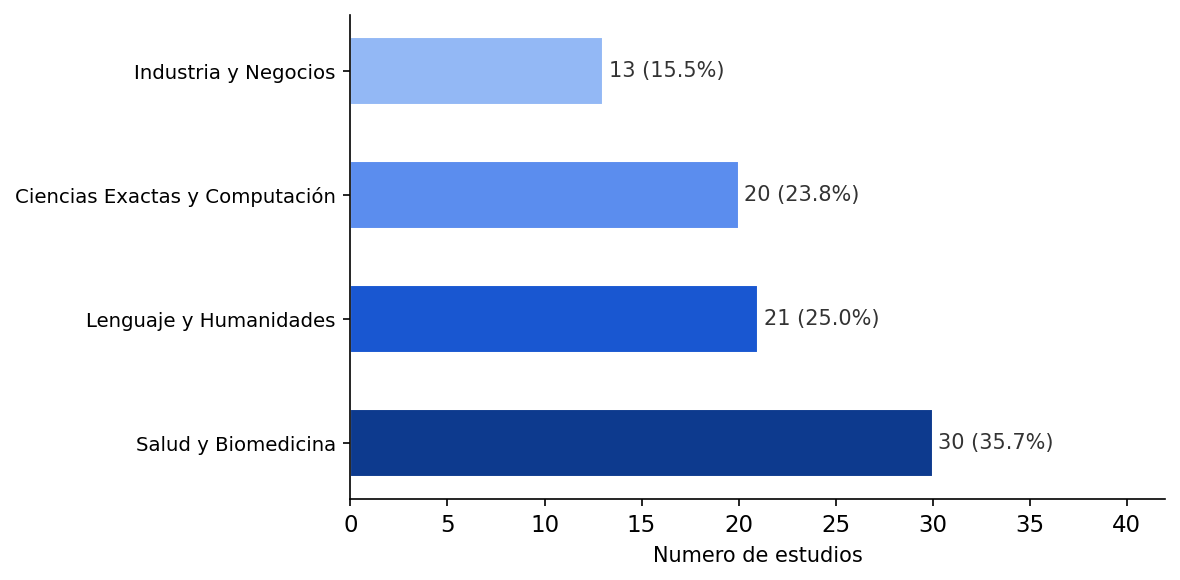

In [8]:
# - Figura 2 -
fig, ax = plt.subplots(figsize=(8, 4))

int_total = int(sr_dominios.sum())
lst_colores_dom = list(PALETTE_DOMINIOS.values())
bars = ax.barh(list(sr_dominios.index), list(sr_dominios.values),
               color=lst_colores_dom, edgecolor="white", height=0.55)

for bar, int_val, str_color in zip(bars, sr_dominios.values, lst_colores_dom):
    flt_pct = int_val / int_total * 100
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{int_val} ({flt_pct:.1f}%)", va="center", fontsize=10,
            color="#333")

ax.set_xlabel("Numero de estudios", fontsize=10)
ax.set_xlim(0, 42)
ax.tick_params(axis="y", labelsize=9.5)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig2_distribucion_dominios.png")
plt.show();

## <font color='#1957d1'> Figura 3 - Puntuacion promedio por criterio de calidad metodologica </font>

In [9]:
# - Medias por criterio QA (sin QA2, eliminada del CSV) -
dic_qa_labels = {
    "qa1_split":       "QA1 - Split de datos\nreportado",
    "qa3_hyperparams": "QA3 - Configuracion de\nentrenamiento completa",
    "qa4_dataset":     "QA4 - Dataset\ncaracterizado",
}
sr_qa = df_fase3[[*dic_qa_labels]].mean().rename(dic_qa_labels)
sr_qa

QA1 - Split de datos\nreportado                   0.839286
QA3 - Configuracion de\nentrenamiento completa    0.827381
QA4 - Dataset\ncaracterizado                      0.946429
dtype: float64

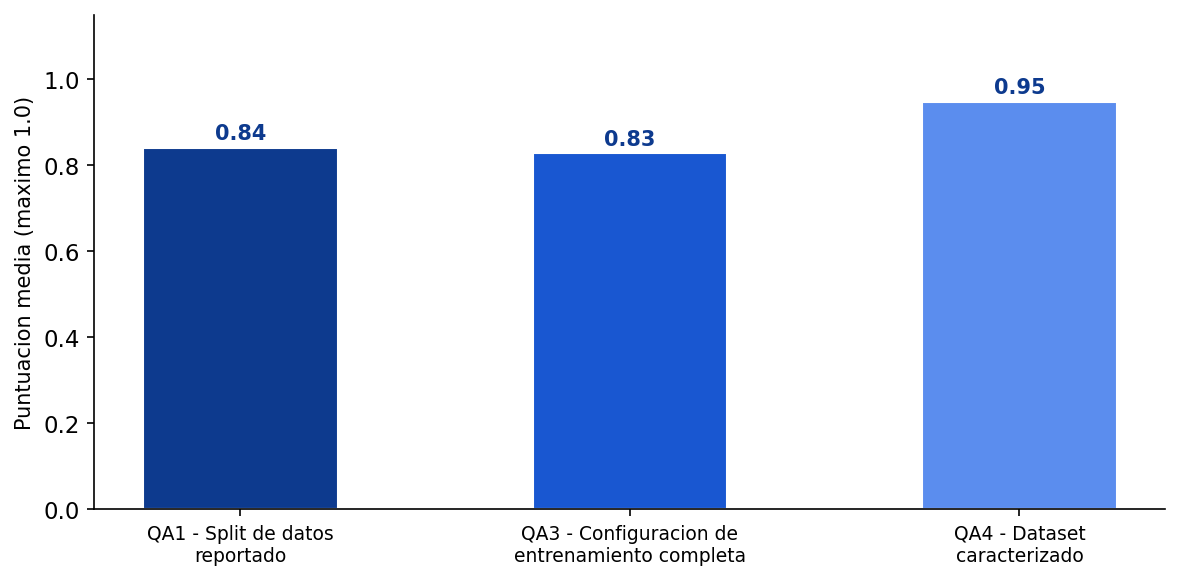

In [10]:
# - Figura 3 -
fig, ax = plt.subplots(figsize=(8, 4))

lst_colores_qa = [COLOR_4, COLOR_1, COLOR_2, COLOR_3]
bars = ax.bar(range(len(sr_qa)), sr_qa.values,
              color=lst_colores_qa, edgecolor="white", width=0.5)

for int_i, flt_val in enumerate(sr_qa.values):
    ax.text(int_i, flt_val + 0.01, f"{flt_val:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color=COLOR_4)

ax.set_xticks(range(len(sr_qa)))
ax.set_xticklabels(sr_qa.index, fontsize=9)
ax.set_ylabel("Puntuacion media (maximo 1.0)", fontsize=10)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig3_criterios_calidad.png")
plt.show();

## <font color='#1957d1'> Figura 4 - Uso de tecnicas de fine-tuning por dominio </font>

In [11]:
# - Leer apendice-datos.md y calcular conteos de tecnicas por dominio (Fig 4a) -
import re

RUTA_APX = Path("../apendice-datos.md")
ORDEN_DOMINIOS = [
    "Salud y Biomedicina",
    "Lenguaje y Humanidades",
    "Ciencias Exactas y Computación",
    "Industria y Negocios",
]
DOMINIOS_SHORT = {
    "Salud y Biomedicina":            "Salud y\nBiomedicina",
    "Lenguaje y Humanidades":         "Lenguaje y\nHumanidades",
    "Ciencias Exactas y Computación": "Ciencias Exactas\ny Computación",
    "Industria y Negocios":           "Industria y\nNegocios",
}

def parse_apendice_datos(path):
    """Lee apendice-datos.md y retorna lista de dicts por paper."""
    papers = []
    current = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip()
            if line.startswith("### "):
                if current:
                    papers.append(current)
                current = {"clave": line[4:].strip()}
            elif line.startswith("- ") and current:
                m = re.match(r"- (.+?):\s*(.+)", line)
                if m:
                    current[m.group(1).strip()] = m.group(2).strip()
    if current:
        papers.append(current)
    return papers

def categorize_technique(tecnica, familia):
    """Categoriza tecnica para Fig 4a en 8 categorias."""
    if tecnica == "QLoRA":
        return "QLoRA"
    if tecnica in ("LoRA + RLHF", "LoRA + RLHF-PPO", "LoRA + GRPO"):
        return "LoRA + Alineación"
    if tecnica in ("Múltiples", "Multi-PEFT", "LoRA + IT") or familia == "Múltiples":
        return "Múltiples"
    if "LoRA" in tecnica:
        return "LoRA"
    if tecnica in ("Full FT", "Full FT (GaLore)", "IT", "SFT + DPO") or familia == "Full FT":
        return "Full FT / SFT"
    if tecnica in ("Adapter", "DAFT"):
        return "Adapter"
    if tecnica in ("Prompt Tuning", "P-Tuning v2", "Prefix Tuning"):
        return "Prompt / Prefix Tuning"
    if tecnica in ("DPO", "ORPO") or familia == "Alineación":
        return "Alineación pura"
    return "Sin clasificar"

lst_papers = parse_apendice_datos(RUTA_APX)
print(f"Papers leidos: {len(lst_papers)}")

CATEGORIAS_TEC = [
    "LoRA",
    "QLoRA",
    "LoRA + Alineación",
    "Full FT / SFT",
    "Adapter",
    "Prompt / Prefix Tuning",
    "Alineación pura",
    "Múltiples",
]
dic_counts = {cat: {d: 0 for d in ORDEN_DOMINIOS} for cat in CATEGORIAS_TEC}
lst_sin_clasificar = []
for p in lst_papers:
    dom = p.get("Dominio", "")
    tec = p.get("Técnica", "")
    fam = p.get("Familia", "")
    if dom in ORDEN_DOMINIOS:
        cat = categorize_technique(tec, fam)
        if cat == "Sin clasificar":
            lst_sin_clasificar.append({"clave": p.get("clave"), "tecnica": tec, "familia": fam})
        else:
            dic_counts[cat][dom] += 1

print("\n=== Conteo por categoria ===")
total_cat = 0
for cat in CATEGORIAS_TEC:
    n = sum(dic_counts[cat].values())
    total_cat += n
    print(f"  {cat}: {n}  |  SyB={dic_counts[cat]['Salud y Biomedicina']}  LyH={dic_counts[cat]['Lenguaje y Humanidades']}  CyC={dic_counts[cat]['Ciencias Exactas y Computación']}  IyN={dic_counts[cat]['Industria y Negocios']}")
print(f"  TOTAL: {total_cat}")
if lst_sin_clasificar:
    print(f"\nSin clasificar ({len(lst_sin_clasificar)}):")
    for item in lst_sin_clasificar:
        print(f"  {item}")
else:
    print("\nTodos los papers clasificados correctamente.")

df_tec = pd.DataFrame(
    {cat: [dic_counts[cat][d] for d in ORDEN_DOMINIOS] for cat in CATEGORIAS_TEC},
    index=[DOMINIOS_SHORT[d] for d in ORDEN_DOMINIOS]
)
df_tec.index.name = "Dominio"
df_tec

Papers leidos: 84

=== Conteo por categoria ===
  LoRA: 50  |  SyB=15  LyH=12  CyC=13  IyN=10
  QLoRA: 10  |  SyB=4  LyH=3  CyC=3  IyN=0
  LoRA + Alineación: 5  |  SyB=2  LyH=0  CyC=1  IyN=2
  Full FT / SFT: 2  |  SyB=2  LyH=0  CyC=0  IyN=0
  Adapter: 4  |  SyB=3  LyH=1  CyC=0  IyN=0
  Prompt / Prefix Tuning: 4  |  SyB=2  LyH=1  CyC=1  IyN=0
  Alineación pura: 2  |  SyB=0  LyH=2  CyC=0  IyN=0
  Múltiples: 7  |  SyB=2  LyH=2  CyC=2  IyN=1
  TOTAL: 84

Todos los papers clasificados correctamente.


,LoRA,QLoRA,LoRA + Alineación,Full FT / SFT,Adapter,Prompt / Prefix Tuning,Alineación pura,Múltiples
Dominio,,,,,,,,
Salud y\nBiomedicina,15,4,2,2,3,2,0,2
Lenguaje y\nHumanidades,12,3,0,0,1,1,2,2
Ciencias Exactas\ny Computación,13,3,1,0,0,1,0,2
Industria y\nNegocios,10,0,2,0,0,0,0,1


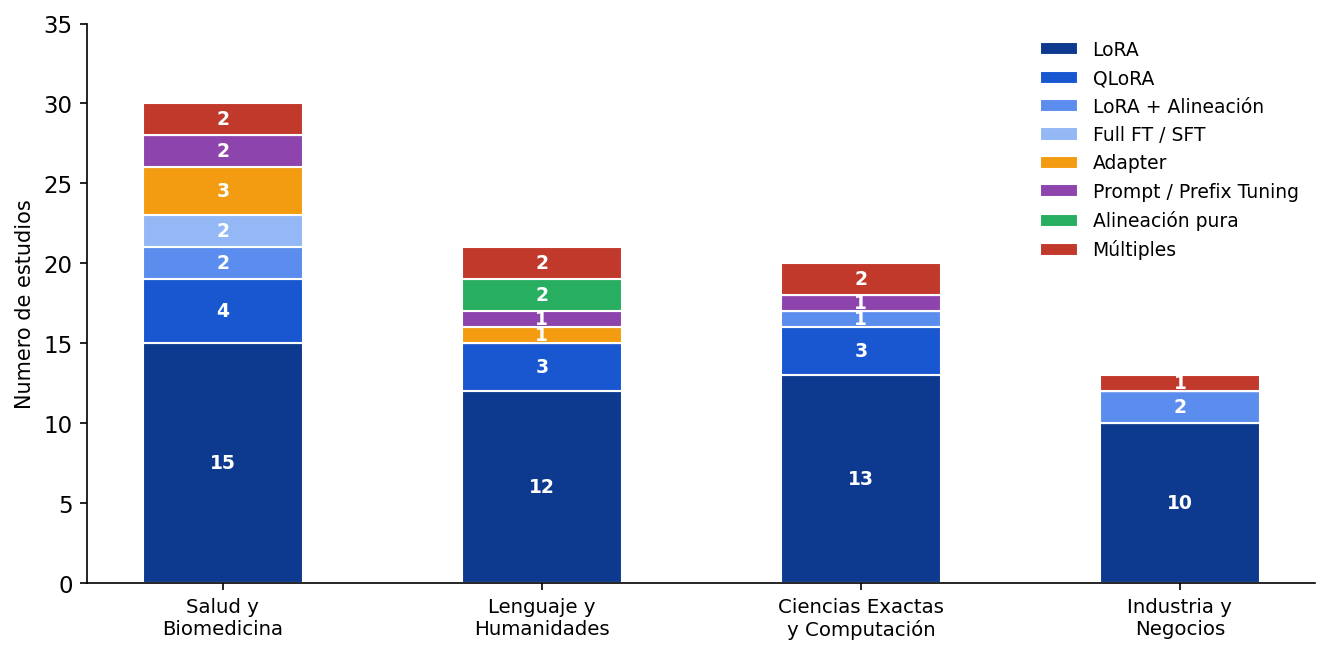

In [12]:
# - Figura 4a - barras apiladas de tecnicas por dominio (8 categorias) -
lst_colores_tec = [
    "#0d3a8e",  # LoRA
    "#1957d1",  # QLoRA
    "#5b8dee",  # LoRA + Alineacion
    "#93b8f5",  # Full FT / SFT
    "#f39c12",  # Adapter
    "#8e44ad",  # Prompt / Prefix Tuning
    "#27ae60",  # Alineacion pura
    "#c0392b",  # Multiples
]
arr_x           = np.arange(len(df_tec))
flt_w           = 0.5

fig, ax = plt.subplots(figsize=(9, 4.5))

arr_bottom = np.zeros(len(df_tec))
for str_tec, str_color in zip(df_tec.columns, lst_colores_tec):
    arr_vals = df_tec[str_tec].values
    bars = ax.bar(arr_x, arr_vals, flt_w, bottom=arr_bottom,
                  label=str_tec, color=str_color, edgecolor="white")
    for int_i, (int_v, flt_b) in enumerate(zip(arr_vals, arr_bottom)):
        if int_v > 0:
            ax.text(int_i, flt_b + int_v / 2, str(int_v),
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")
    arr_bottom = arr_bottom + arr_vals

ax.set_xticks(arr_x)
ax.set_xticklabels(df_tec.index, fontsize=9.5)
ax.set_ylabel("Numero de estudios", fontsize=10)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig4a_tecnicas_por_dominio.png")
plt.show();

                                 Full FT  PEFT  Alineación  Múltiples
Dominio                                                              
Salud y\nBiomedicina                   2    24           0          4
Lenguaje y\nHumanidades                0    18           2          1
Ciencias Exactas\ny Computación        0    19           0          1
Industria y\nNegocios                  0    10           0          3


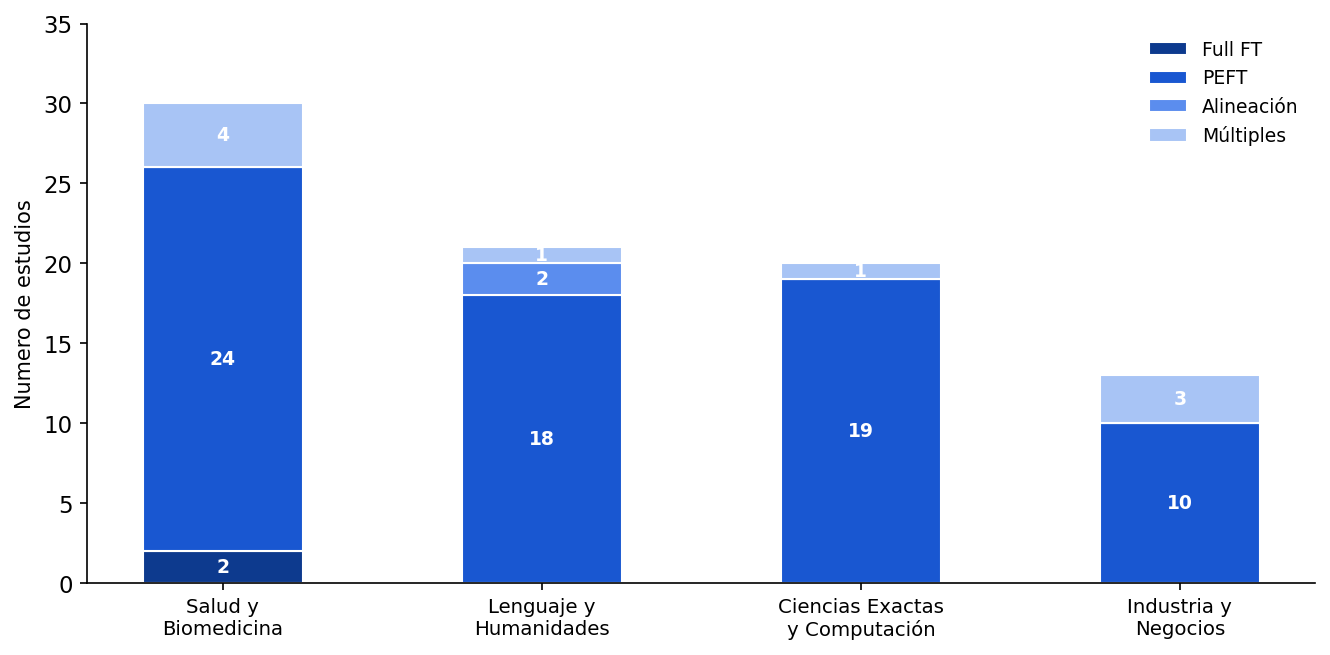

In [13]:
# - Figura 4b - familias por dominio desde apendice-datos.md -
# CAMBIO: "Full FT" (antes "Full Fine-Tuning") + "Múltiples" agregada con COLOR_3
FAMILIAS = ["Full FT", "PEFT", "Alineación", "Múltiples"]
lst_colores_fam = [COLOR_4, COLOR_1, COLOR_2, COLOR_3]

dic_fam = {fam: {d: 0 for d in ORDEN_DOMINIOS} for fam in FAMILIAS}
for p in lst_papers:
    dom = p.get("Dominio", "")
    fam = p.get("Familia", "")
    if dom in ORDEN_DOMINIOS and fam in FAMILIAS:
        dic_fam[fam][dom] += 1

df_fam = pd.DataFrame(
    {fam: [dic_fam[fam][d] for d in ORDEN_DOMINIOS] for fam in FAMILIAS},
    index=[DOMINIOS_SHORT[d] for d in ORDEN_DOMINIOS]
)
df_fam.index.name = "Dominio"
print(df_fam)

arr_x  = np.arange(len(df_fam))
flt_w  = 0.5

fig, ax = plt.subplots(figsize=(9, 4.5))

arr_bottom = np.zeros(len(df_fam))
for str_fam, str_color in zip(df_fam.columns, lst_colores_fam):
    arr_vals = df_fam[str_fam].values
    bars = ax.bar(arr_x, arr_vals, flt_w, bottom=arr_bottom,
                  label=str_fam, color=str_color, edgecolor="white")
    for int_i, (int_v, flt_b) in enumerate(zip(arr_vals, arr_bottom)):
        if int_v > 0:
            ax.text(int_i, flt_b + int_v / 2, str(int_v),
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")
    arr_bottom = arr_bottom + arr_vals

ax.set_xticks(arr_x)
ax.set_xticklabels(df_fam.index, fontsize=9.5)
ax.set_ylabel("Numero de estudios", fontsize=10)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig4b_familias_por_dominio.png")
plt.show();

## <font color='#1957d1'> Figura 5 - Mejoras de rendimiento reportadas por dominio </font>

In [14]:
# - Leer deltas desde apendice-datos.md -
def parse_delta(str_val):
    """Convierte string de delta a float. Retorna None si es --- o no parseable."""
    if str_val == "---":
        return None
    str_val = str_val.replace("≈", "").strip()
    str_val = str_val.replace("%", "").replace("+", "").replace(",", ".")
    try:
        return float(str_val)
    except ValueError:
        return None

lst_rows = []
for p in lst_papers:
    dom = p.get("Dominio", "")
    delta_str = p.get("Delta", "---")
    flt = parse_delta(delta_str)
    if flt is not None and dom in ORDEN_DOMINIOS:
        lst_rows.append({"Dominio": dom, "Delta": flt})

df_deltas = pd.DataFrame(lst_rows)
print(f"Papers con delta numerico: {len(df_deltas)}")

def clasificar(flt_val):
    if flt_val > 0:
        return "Mejora positiva"
    elif flt_val == 0:
        return "Resultado igual al baseline"
    else:
        return "Resultado inferior al baseline"

df_deltas["categoria"] = df_deltas["Delta"].apply(clasificar)

df_conteo = (
    df_deltas
    .groupby(["Dominio", "categoria"])
    .size()
    .unstack(fill_value=0)
    .reindex(list(PALETTE_DOMINIOS.keys()))
)
df_conteo

Papers con delta numerico: 30


categoria,Mejora positiva,Resultado inferior al baseline
Dominio,,
Salud y Biomedicina,9,0
Lenguaje y Humanidades,9,0
Ciencias Exactas y Computación,5,1
Industria y Negocios,6,0


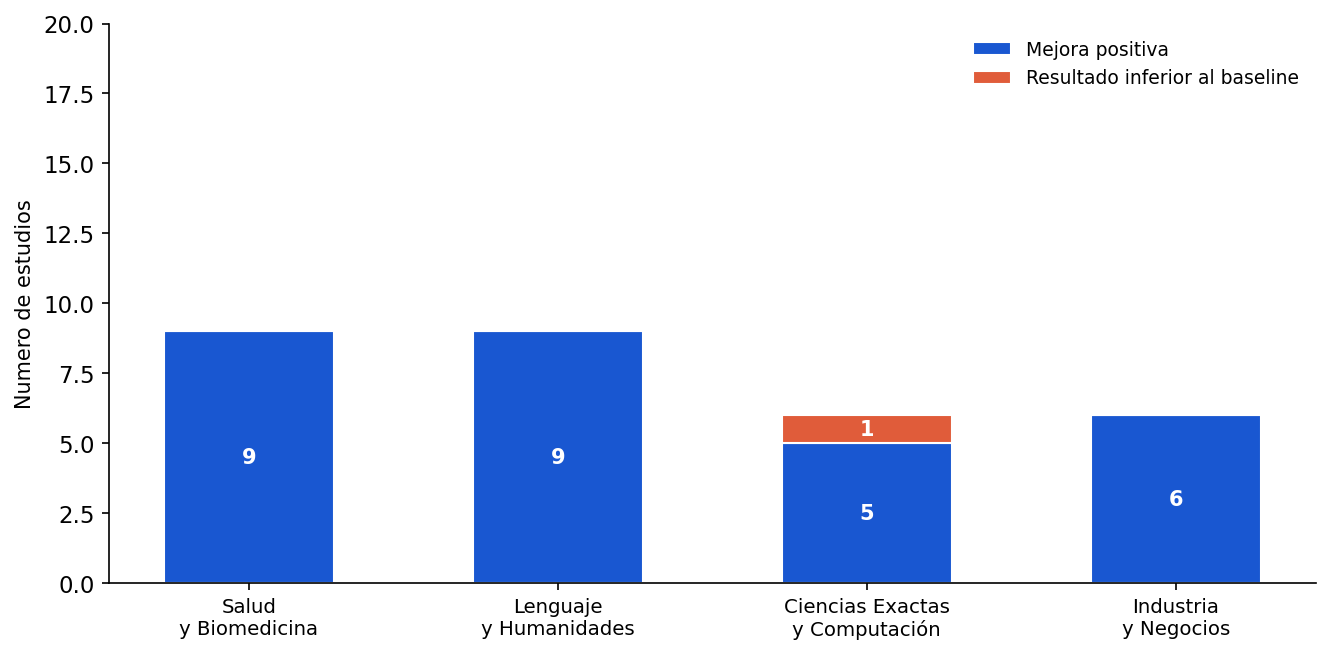

In [15]:
# - Figura 5 - conteo de estudios con mejora positiva vs sin mejora -
lst_categorias = ["Mejora positiva", "Resultado igual al baseline", "Resultado inferior al baseline"]
lst_colores_cat = ["#1957d1", "#93b8f5", "#e05c3a"]
arr_x  = np.arange(len(df_conteo))
flt_w  = 0.55

fig, ax = plt.subplots(figsize=(9, 4.5))

arr_bottom = np.zeros(len(df_conteo))
for str_cat, str_color in zip(lst_categorias, lst_colores_cat):
    if str_cat not in df_conteo.columns:
        continue
    arr_vals = df_conteo[str_cat].values
    bars = ax.bar(arr_x, arr_vals, flt_w, bottom=arr_bottom,
                  label=str_cat, color=str_color, edgecolor="white")
    for int_i, (int_v, flt_b) in enumerate(zip(arr_vals, arr_bottom)):
        if int_v > 0:
            ax.text(int_i, flt_b + int_v / 2, str(int_v),
                    ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")
    arr_bottom = arr_bottom + arr_vals

ax.set_xticks(arr_x)
ax.set_xticklabels(
    [d.replace(" y ", "\ny ") for d in df_conteo.index],
    fontsize=9.5
)
ax.set_ylabel("Numero de estudios", fontsize=10)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.set_ylim(0, 20)

plt.tight_layout()
plt.savefig(RUTA_OUT / "fig5_direccion_mejoras.png")
plt.show();

## <font color='#1957d1'> Exportacion </font>

In [16]:
# # - Archivos exportados -
# for str_arch in sorted(RUTA_OUT.glob("*.png")):
#     print(str_arch)